<a href="https://colab.research.google.com/github/osalex800/Analisis-y-visualizacion-de-datos/blob/main/Ejercicio_2_Unidad_2_Regresi%C3%B3n_utilizando_R_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#install.packages("ISLR2")
install.packages("ggplot2")
install.packages("readr")

# Cargar librerías necesarias
#library(ISLR2)
library(ggplot2)
library(readr)
# Cargar datos de publicidad
#data(Advertising) # Variables: TV, Radio, Newspaper, Sales
#data(Credit)
Advertising<- read.csv("Advertising.csv")



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in file(file, "rt"):
“cannot open file 'Advertising.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [ ]:
# Ajustar modelo de regresión lineal simple
# Predecir ventas en función del presupuesto de TV
modelo_simple <- lm(Sales ~ TV, data = Advertising)
# Ver resumen completo del modelo
summary(modelo_simple)


Call:
lm(formula = Sales ~ TV, data = Advertising)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.3860 -1.9545 -0.1913  2.0671  7.2124 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 7.032594   0.457843   15.36   <2e-16 ***
TV          0.047537   0.002691   17.67   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.259 on 198 degrees of freedom
Multiple R-squared:  0.6119,	Adjusted R-squared:  0.6099 
F-statistic: 312.1 on 1 and 198 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'


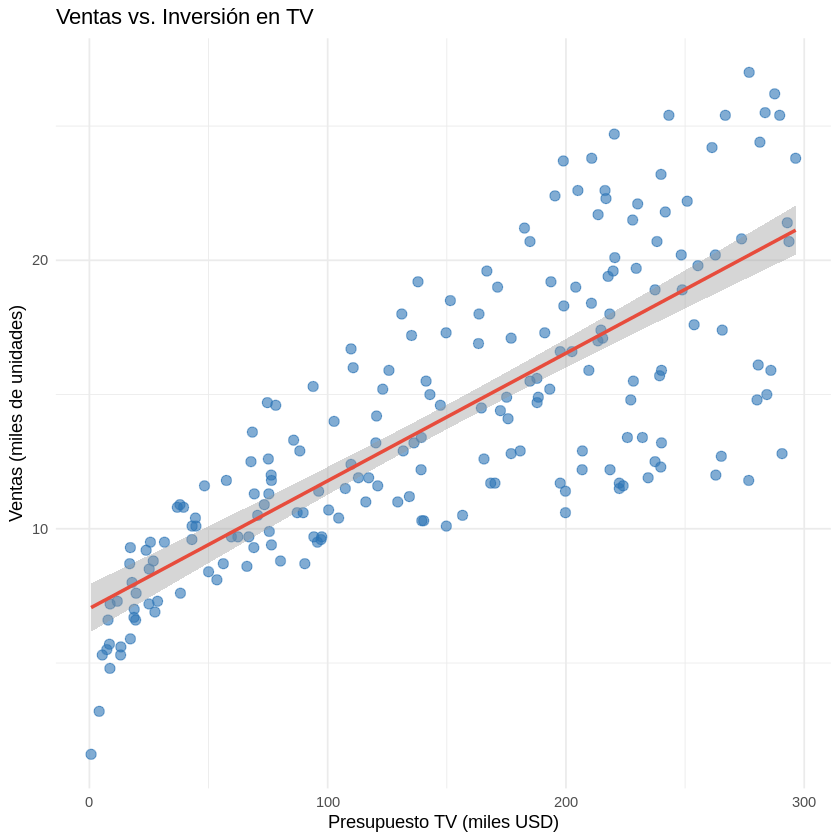

In [ ]:
# Visualizar la recta de regresión
ggplot(Advertising, aes(x = TV, y = Sales)) + geom_point(color = '#2E75B6', alpha = 0.6, size = 2.5) + geom_smooth(method = 'lm', color = '#E74C3C', se = TRUE) + labs(title = 'Ventas vs. Inversión en TV', x = 'Presupuesto TV (miles USD)', y = 'Ventas (miles de unidades)') + theme_minimal()

In [ ]:
# Modelo de regresión múltiple
modelo_mult <- lm(Sales ~ TV + Radio + Newspaper, Advertising)
summary(modelo_mult)
# Resultado esperado (aproximado):
# Coefficients: Estimate Std. Error t value Pr(&gt;|t|)
# (Intercept) 2.9389 0.3119 9.422 &lt;2e-16 ***
# TV 0.0458 0.0014 32.809 &lt;2e-16 ***
# radio 0.1885 0.0086 21.893 &lt;2e-16 ***
# newspaper -0.0010 0.0059 -0.177 0.860
# ---
# Multiple R-squared: 0.8972, Adjusted R-squared: 0.8956
# Predicción para nuevos datos
nuevos_datos <- data.frame(TV = 150, Radio = 25, Newspaper = 30)
predict(modelo_mult, newdata = nuevos_datos, interval = 'prediction', level = 0.95)


Call:
lm(formula = Sales ~ TV + Radio + Newspaper, data = Advertising)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
TV           0.045765   0.001395  32.809   <2e-16 ***
Radio        0.188530   0.008611  21.893   <2e-16 ***
Newspaper   -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16


,fit,lwr,upr
1,14.48571,11.15318,17.81824


In [ ]:
# Ejemplo con variable categórica: ShelveLoc (Good/Bad/Medium)
Carseats<- read.csv("Carseats.csv")


In [ ]:
modelo_carseat <- lm(Sales ~ Price + ShelveLoc + Age + Income, data = Carseats)
summary(modelo_carseat)



Call:
lm(formula = Sales ~ Price + ShelveLoc + Age + Income, data = Carseats)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.5189 -1.1368 -0.1204  1.2244  5.1830 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     13.787882   0.597134  23.090  < 2e-16 ***
Price           -0.059220   0.003604 -16.430  < 2e-16 ***
ShelveLocGood    4.997441   0.252486  19.793  < 2e-16 ***
ShelveLocMedium  2.044343   0.207854   9.835  < 2e-16 ***
Age             -0.049810   0.005262  -9.466  < 2e-16 ***
Income           0.015155   0.003037   4.990 9.09e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.691 on 394 degrees of freedom
Multiple R-squared:  0.646,	Adjusted R-squared:  0.6415 
F-statistic: 143.8 on 5 and 394 DF,  p-value: < 2.2e-16


In [ ]:
# R crea automáticamente:
# ShelveLocGood → 1 si ubicación es &#39;Good&#39;, 0 si no
# ShelveLocMedium → 1 si ubicación es &#39;Medium&#39;, 0 si no
# (Bad es la categoría de referencia)
# Verificar qué contraste usa R
contrasts(as.factor(Carseats$ShelveLoc))

,Good,Medium
Bad,0,0
Good,1,0
Medium,0,1


In [ ]:
# Interacción entre TV y radio
# El efecto de TV puede amplificarse cuando radio también es alto
modelo_interact <- lm(Sales ~ TV * Radio, data = Advertising)
summary(modelo_interact)
# Equivalente a:
# lm(sales ~ TV + radio + TV:radio, data = Advertising)
# Modelo con transformación logarítmica y cuadrática
modelo_poly <- lm(Sales ~ TV + I(TV^2) + Radio, data = Advertising)
summary(modelo_poly)


Call:
lm(formula = Sales ~ TV * Radio, data = Advertising)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.3366 -0.4028  0.1831  0.5948  1.5246 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 6.750e+00  2.479e-01  27.233   <2e-16 ***
TV          1.910e-02  1.504e-03  12.699   <2e-16 ***
Radio       2.886e-02  8.905e-03   3.241   0.0014 ** 
TV:Radio    1.086e-03  5.242e-05  20.727   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9435 on 196 degrees of freedom
Multiple R-squared:  0.9678,	Adjusted R-squared:  0.9673 
F-statistic:  1963 on 3 and 196 DF,  p-value: < 2.2e-16



Call:
lm(formula = Sales ~ TV + I(TV^2) + Radio, data = Advertising)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.3860 -0.8822 -0.0498  0.9613  3.5725 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.288e+00  3.588e-01   3.588 0.000421 ***
TV           7.844e-02  4.985e-03  15.736  < 2e-16 ***
I(TV^2)     -1.136e-04  1.677e-05  -6.775 1.42e-10 ***
Radio        1.930e-01  7.293e-03  26.465  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.517 on 196 degrees of freedom
Multiple R-squared:  0.9167,	Adjusted R-squared:  0.9154 
F-statistic:   719 on 3 and 196 DF,  p-value: < 2.2e-16


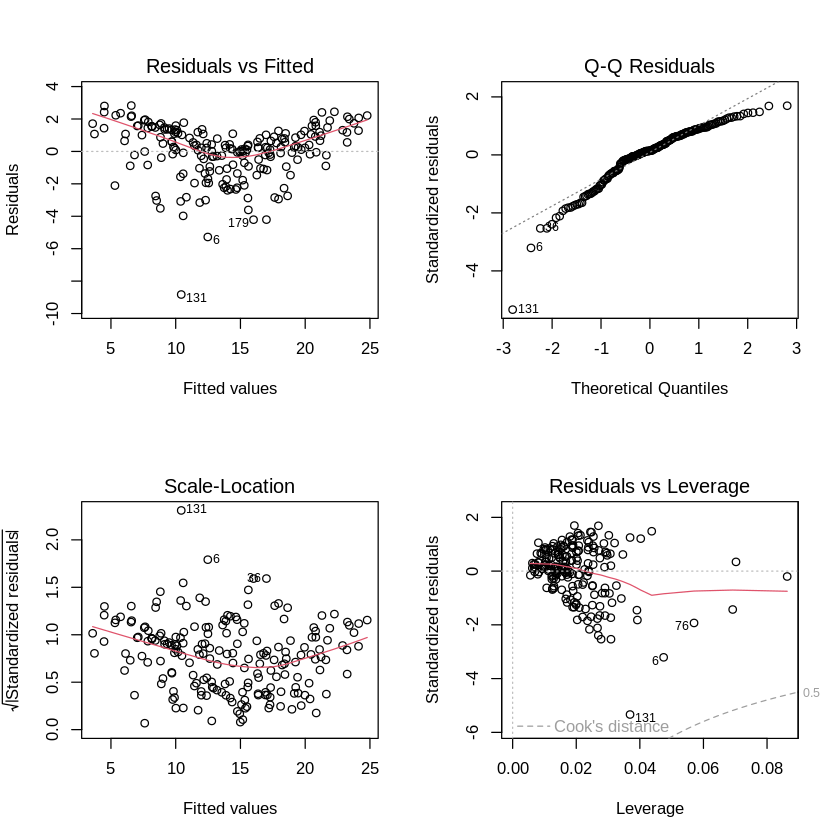

In [ ]:
# Gráficos de diagnóstico completos
par(mfrow = c(2, 2)) # Layout 2x2
plot(modelo_mult) # 4 gráficos automáticos
# Gráfico 1 - Residuals vs Fitted: detecta no linealidad
# Gráfico 2 - Q-Q Plot: evalúa normalidad de residuos
# Gráfico 3 - Scale-Location: evalúa homocedasticidad
# Gráfico 4 - Residuals vs Leverage: detecta puntos influyentes


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo_mult
BP = 5.1329, df = 3, p-value = 0.1623


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




TV     Radio Newspaper 
 1.004611  1.144952  1.145187

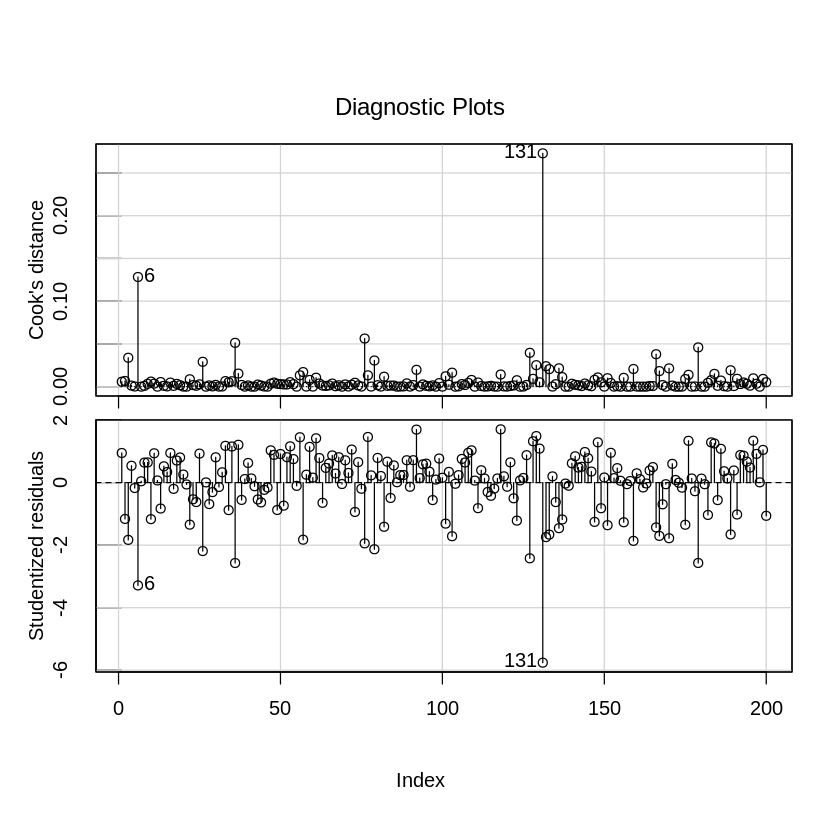

In [ ]:
# ── Prueba formal de homocedasticidad ──
install.packages("lmtest")
library(lmtest)
bptest(modelo_mult) # Breusch-Pagan: H0 = homocedasticidad
# ── Multicolinealidad ──
install.packages("car")
library(car)
vif(modelo_mult) # VIF &lt; 5 = aceptable, &gt;10 = problema severo
# ── Observaciones influyentes ──
influenceIndexPlot(modelo_mult, vars = c('Cook', 'Studentized'))
# Distancia de Cook &gt; 1 sugiere observación muy influyente

# Parte 2

In [3]:
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [4]:
install.packages("Metrics")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
install.packages("ISLR2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [7]:
library(ISLR2)
data(Advertising)

Warning message in data(Advertising):
“data set ‘Advertising’ not found”


In [8]:
library(caret)
library(Metrics)
library(readr)
library(ISLR2)
# ── Método 1: Train/Test Split (70/30) ──
set.seed(123) # Reproducibilidad
Advertising<-read.csv("Advertising.csv")
n <- nrow(Advertising)
train_idx <- sample(1:n, size = 0.7 * n)
train_data <- Advertising[train_idx, ]
test_data <- Advertising[-train_idx, ]
modelo_train <- lm(Sales ~ TV + Radio + Newspaper, data = train_data)
pred_test <- predict(modelo_train, newdata = test_data)


Loading required package: lattice


Attaching package: ‘Metrics’


The following objects are masked from ‘package:caret’:

    precision, recall




In [9]:
# Métricas en test set
rmse_test <- rmse(test_data$Sales, pred_test)
mae_test <- mae(test_data$Sales, pred_test)
cat('RMSE test:', round(rmse_test, 3), '\n')
cat('MAE test:', round(mae_test, 3), '\n')


RMSE test: 1.524 
MAE test: 1.289 


In [10]:
head(train_data)

,X,TV,Radio,Newspaper,Sales
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
159,159,11.7,36.9,45.2,7.3
179,179,276.7,2.3,23.7,11.8
14,14,97.5,7.6,7.2,9.7
195,195,149.7,35.6,6.0,17.3
170,170,284.3,10.6,6.4,15.0
50,50,66.9,11.7,36.8,9.7


In [11]:
# ── Método 2: Validación Cruzada 10-Fold ──
control <- trainControl(method = 'cv', number = 10)
modelo_cv <- train(Sales ~ TV + Radio + Newspaper, method = 'lm', trControl = control, data=Advertising)
print(modelo_cv) # Muestra RMSE promedio de los 10 folds

Linear Regression 

200 samples
  3 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 180, 180, 181, 180, 180, 179, ... 
Resampling results:

  RMSE      Rsquared   MAE   
  1.668825  0.9036202  1.2792

Tuning parameter 'intercept' was held constant at a value of TRUE


In [12]:
install.packages("MASS")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [13]:
install.packages("leaps")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [14]:
library(MASS) # Para stepAIC
library(leaps) # Para regsubsets (mejor subconjunto)
# ── Selección Stepwise (AIC) ──
modelo_full <- lm(Sales ~ ., data = Advertising)
modelo_step <- stepAIC(modelo_full, direction = 'both', trace = FALSE)
summary(modelo_step)


Attaching package: ‘MASS’


The following object is masked from ‘package:ISLR2’:

    Boston





Call:
lm(formula = Sales ~ TV + Radio, data = Advertising)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.7977 -0.8752  0.2422  1.1708  2.8328 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.92110    0.29449   9.919   <2e-16 ***
TV           0.04575    0.00139  32.909   <2e-16 ***
Radio        0.18799    0.00804  23.382   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.681 on 197 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8962 
F-statistic: 859.6 on 2 and 197 DF,  p-value: < 2.2e-16


In [15]:
# ── Mejor Subconjunto (Exhaustivo) ──
reg_subset <- regsubsets(Sales ~ ., data = Advertising, nvmax = 4)
reg_summary <- summary(reg_subset)


In [16]:
# Identificar mejor modelo según BIC
mejor_bic <- which.min(reg_summary$bic)
coef(reg_subset, mejor_bic)


(Intercept)          TV       Radio 
 2.92109991  0.04575482  0.18799423

In [17]:
# ── Comparar modelos con ANOVA ──
modelo_reducido <- lm(Sales ~ TV + Radio, data = Advertising)
modelo_completo <- lm(Sales ~ TV + Radio + Newspaper, data = Advertising)
anova(modelo_reducido, modelo_completo)
# Si p < 0.05 → el modelo reducido es preferible

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,197,556.9140,NA,NA,NA,NA
2,196,556.8253,1,0.08871717,0.03122805,0.8599151


In [18]:
# Ejemplo: modelo de demanda con elasticidad precio
# log(Ventas) = β₀ + β₁·log(Precio) + β₂·Promo + β₃·Estacion + ε
# Generar datos de ejemplo
set.seed(42)
n <- 120 # 10 años de datos mensuales
precio <- runif(n, 10, 50)
promo <- rbinom(n, 1, 0.3) # 30% de meses con promoción
estacion <- factor(rep(1:4, length.out = n)) # Trimestres
ventas <- 5000 * precio^(-1.3) * exp(0.4*promo) * rnorm(n, 1, 0.05)
df_ventas <- data.frame(ventas, precio, promo, estacion)
# Modelo log-log (elasticidad constante)
modelo_demanda <- lm(log(ventas) ~ log(precio) + promo + estacion,
data = df_ventas)
summary(modelo_demanda)
# Interpretación: β₁ = elasticidad precio
# Si β₁ = -1.3 → un aumento del 1% en precio reduce ventas 1.3%


Call:
lm(formula = log(ventas) ~ log(precio) + promo + estacion, data = df_ventas)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.108397 -0.033700  0.000402  0.029002  0.107231 

Coefficients:
             Estimate Std. Error  t value Pr(>|t|)    
(Intercept)  8.551518   0.031388  272.443   <2e-16 ***
log(precio) -1.314523   0.009048 -145.277   <2e-16 ***
promo        0.398609   0.008771   45.447   <2e-16 ***
estacion2    0.010562   0.011577    0.912    0.364    
estacion3    0.014560   0.011603    1.255    0.212    
estacion4    0.008430   0.011626    0.725    0.470    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.04475 on 114 degrees of freedom
Multiple R-squared:  0.9951,	Adjusted R-squared:  0.9949 
F-statistic:  4629 on 5 and 114 DF,  p-value: < 2.2e-16


In [19]:
# Ejemplo: modelo de tiempo de ciclo en manufactura
# Predecir tiempo de ciclo (min) desde variables de proceso
set.seed(7)
n <- 200
temperatura <- runif(n, 180, 240) # °C
presion <- runif(n, 50, 120) # PSI
velocidad <- runif(n, 10, 80) # RPM
operador_exp <- sample(1:5, n, replace = TRUE) # años experiencia
tiempo_ciclo <- 45 + 0.1*temperatura - 0.05*presion + 0.2*velocidad - 1.5*operador_exp + rnorm(n, 0, 3)
df_proceso <- data.frame(tiempo_ciclo, temperatura, presion, velocidad, operador_exp)
modelo_proceso <- lm(tiempo_ciclo ~ ., data = df_proceso)
summary(modelo_proceso)
# Predicción para configuración óptima
config_optima <- data.frame(temperatura = 200, presion = 100,velocidad = 50, operador_exp = 4)
predict(modelo_proceso, newdata = config_optima, interval = 'prediction', level = 0.95)


Call:
lm(formula = tiempo_ciclo ~ ., data = df_proceso)

Residuals:
   Min     1Q Median     3Q    Max 
-8.628 -2.233 -0.009  2.165  8.325 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  46.90254    3.11081  15.077  < 2e-16 ***
temperatura   0.09907    0.01350   7.337 5.74e-12 ***
presion      -0.06326    0.01162  -5.442 1.57e-07 ***
velocidad     0.18589    0.01084  17.142  < 2e-16 ***
operador_exp -1.48111    0.15251  -9.712  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.139 on 195 degrees of freedom
Multiple R-squared:  0.6776,	Adjusted R-squared:  0.671 
F-statistic: 102.4 on 4 and 195 DF,  p-value: < 2.2e-16


,fit,lwr,upr
1,63.76103,57.52855,69.9935


In [20]:
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [21]:
install.packages("broom")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [22]:
library(tidyverse)
library(broom) # Para convertir outputs de lm() a tibbles
# Ajustar y extraer resultados en formato tidy
modelo_tidy <- lm(Sales ~ TV + Radio, data = Advertising)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ stringr   1.6.0
✔ forcats   1.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [23]:
# Tabla de coeficientes limpia
tidy(modelo_tidy, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~round(., 4)))


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.9211,0.2945,9.9192,0,2.3403,3.5019
TV,0.0458,0.0014,32.9087,0,0.0430,0.0485
Radio,0.1880,0.0080,23.3824,0,0.1721,0.2038


In [24]:
# Métricas de ajuste del modelo
glance(modelo_tidy)


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.8971943,0.8961505,1.681361,859.6177,4.827362e-98,2,-386.197,780.3941,793.5874,556.914,197,200


In [30]:
# Valores ajustados y residuos
augment(modelo_tidy) %>% select(Sales, .fitted, .resid, .hat, .cooksd) %>% head(10)

Sales,.fitted,.resid,.hat,.cooksd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
22.1,20.555465,1.54453537,0.014025370,4.058218e-03
10.4,12.345362,-1.94536229,0.018782927,8.705444e-03
9.3,12.337018,-3.03701773,0.029518412,3.408552e-02
18.5,17.617116,0.88288404,0.012416937,1.170123e-03
12.9,13.223908,-0.32390813,0.009513853,1.199665e-04
7.2,12.512084,-5.31208449,0.034651819,1.237214e-01
11.8,11.718212,0.08178759,0.012932049,1.046899e-05
13.2,12.105516,1.09448447,0.005757034,8.226021e-04
4.8,3.709379,1.09062080,0.027077911,4.012023e-03


Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.


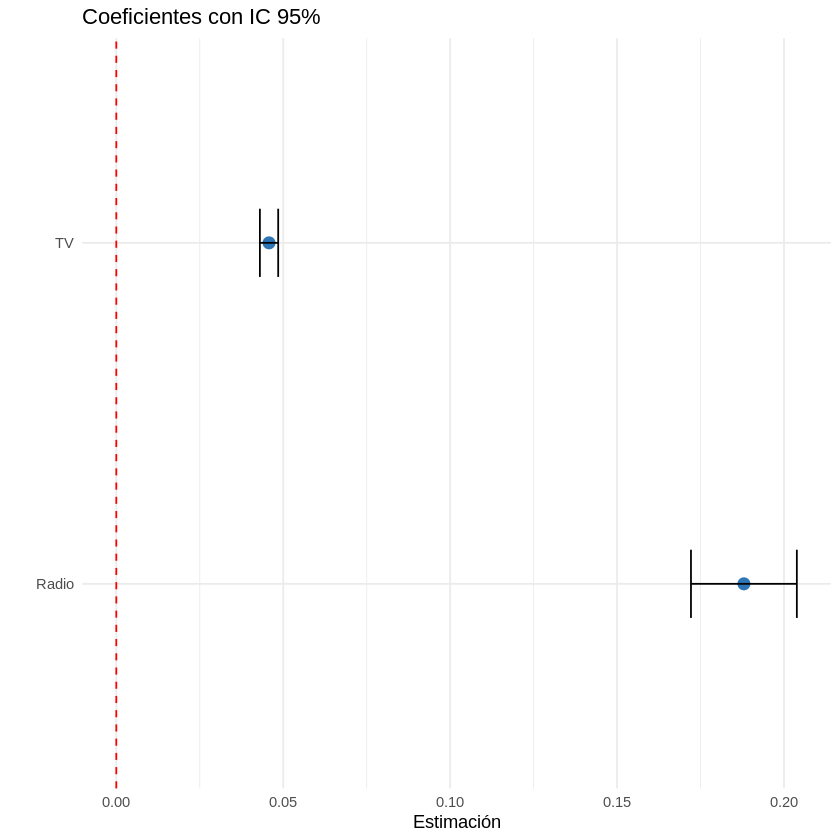

In [31]:
# Gráfico de coeficientes con intervalos de confianza
tidy(modelo_tidy, conf.int = TRUE) %>%
  filter(term != '(Intercept)') %>%
  ggplot(aes(x = estimate, y = term)) + geom_point(color = '#2E75B6', size = 3) + geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.2) + geom_vline(xintercept = 0, linetype = 'dashed', color = 'red') +
  labs(title = 'Coeficientes con IC 95%', x = 'Estimación', y = '') + theme_minimal()